In [1]:
import pandas as pd

In [2]:
survey = pd.read_excel('AA2024_Cleandata_toSPSS.xlsx')

In [3]:
survey.head()


,SessionID,LinkName,Language,RefGroup,trimet_employee,county,county.other.TEXT,zip_code,gen_direction,local_problem.TEXT,...,essential_worker_banner,rider_banner,ridership_banner,future_rider_banner,future_ridership_banner,trimet_dependent_banner,approve_gen_banner,recommend_banner,safe_bus_banner,safe_MAX_banner
0,1716582350_6650f7ced978d4.47222377,email2,English,lnks.gd,No,Multnomah,NaN,97266,Wrong track,"The lack of TRULY affordable housing, combined...",...,NaN,Current rider,Occasional rider (I ride several times a month),Future ride more: yes,More than now,Yes,Disapprove,Detractor (0-6),Safe (5-7),Not Safe (1-3)
1,1716579387_6650ec3b1446a5.31320520,email2,English,lnks.gd,No,Multnomah,NaN,97212,I'm not sure,More security,...,NaN,Current rider,Infrequent rider (I ride less than once a month),Future ride more: no,About the same as now,NaN,Approve,Detractor (0-6),Safe (5-7),Neutral (4)
2,1716591369_66511b097c2ea1.40755288,email2,English,lnks.gd,No,Multnomah,NaN,97239,I'm not sure,Safety,...,NaN,Current rider,Frequent rider (I ride almost every day),Future ride more: no,About the same as now,NaN,Approve,Promoter (9-10),Safe (5-7),Not Safe (1-3)
3,1716581618_6650f4f26388b3.42574860,email2,English,lnks.gd,No,Washington,NaN,97123,I'm not sure,crime,...,NaN,Current rider,Frequent rider (I ride almost every day),Future ride more: no,About the same as now,Yes,Approve,Passive (7-8),Safe (5-7),Safe (5-7)
4,1717119224_665928f86624c5.28976510,email2,English,reddit,No,Multnomah,NaN,97209,Wrong track,Homelessness / drug use / violent street groups,...,NaN,Current rider,Frequent rider (I ride almost every day),Future ride more: no,About the same as now,Yes,Approve,Promoter (9-10),Safe (5-7),Safe (5-7)


In [4]:
survey.shape

(4208, 388)

In [5]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4208 entries, 0 to 4207
Columns: 388 entries, SessionID to safe_MAX_banner
dtypes: float64(298), int64(1), object(89)
memory usage: 12.5+ MB


In [6]:
otp_related_cols = [col for col in survey.columns if 'otp' in col.lower() or 
                    'on_time' in col.lower() or 'reliable' in col.lower() or
                    'schedule' in col.lower() or 'late' in col.lower()]
print(otp_related_cols)


['reliable_bus', 'reliable_MAX', 'ride_less.work_schedule', 'ride_more.work_schedule', 'ride_time.late']


In [7]:
# drop reliable_MAX
survey = survey.drop(columns=['reliable_MAX'])


In [8]:
# Check how riders rate bus reliability
# Check how people rate bus reliability
survey['reliable_bus'].value_counts(dropna=False)


reliable_bus
6                         1138
5                         1137
7: Very reliable           653
4                          631
3                          295
NaN                        191
2                          104
1: Not at all reliable      59
Name: count, dtype: int64

In [9]:
# See how bus reliability links to future ridership
# Cross-tab of bus reliability vs future ridership plans
pd.crosstab(survey['reliable_bus'], survey['future_ridership_banner'], normalize='index')


future_ridership_banner,About the same as now,I won't ride TriMet at all,I'm not sure,Less than now,More than now
reliable_bus,,,,,
1: Not at all reliable,0.473684,0.280702,0.122807,0.087719,0.035088
2,0.401961,0.254902,0.117647,0.147059,0.078431
3,0.544218,0.183673,0.071429,0.136054,0.064626
4,0.545016,0.192926,0.102894,0.067524,0.091640
5,0.671429,0.082143,0.070536,0.056250,0.119643
6,0.696191,0.065545,0.067316,0.047830,0.123118
7: Very reliable,0.682737,0.045101,0.073095,0.037325,0.161742


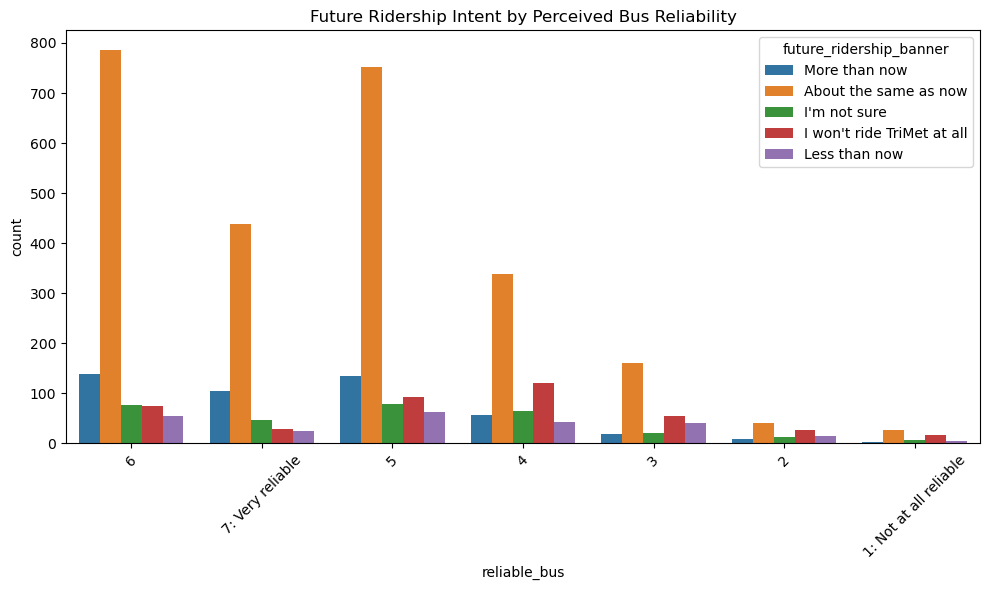

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar chart of future ridership by perceived bus reliability
plt.figure(figsize=(10,6))
sns.countplot(data=survey, x='reliable_bus', hue='future_ridership_banner')
plt.title('Future Ridership Intent by Perceived Bus Reliability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# Explore the relationship between lateness and bus reliability
# Crosstab of riders who mention lateness vs how reliable they think buses are
pd.crosstab(survey['ride_time.late'], survey['reliable_bus'], normalize='index')


reliable_bus,1: Not at all reliable,2,3,4,5,6,7: Very reliable
ride_time.late,,,,,,,
0.0,0.009936,0.020227,0.073101,0.138041,0.280341,0.302697,0.175656
1.0,0.024055,0.032646,0.056701,0.144330,0.333333,0.257732,0.151203


In [12]:
# See how lateness affects likelihood to recommend TriMet
pd.crosstab(survey['ride_time.late'], survey['recommend_banner'], normalize='index')


recommend_banner,Detractor (0-6),Passive (7-8),Promoter (9-10)
ride_time.late,,,
0.0,0.399215,0.267570,0.333214
1.0,0.369603,0.298791,0.331606


In [13]:
# Analyze work schedule constraints
# If riders would ride less due to work schedule
pd.crosstab(survey['ride_less.work_schedule'], survey['reliable_bus'], normalize='index')

# If they would ride more if work schedule aligned
pd.crosstab(survey['ride_more.work_schedule'], survey['future_ridership_banner'], normalize='index')


future_ridership_banner,I'm not sure,More than now
ride_more.work_schedule,,
0.0,0.428161,0.571839
1.0,0.119048,0.880952


In [14]:
# Use rider perception as a proxy for OTP experience
survey['local_problem.TEXT'].sample(20).tolist()


['homelessness and vandalism',
 'Homelessness',
 'Homelessness and social services',
 nan,
 'There have been challenges with unhoused people but I feel that Portland is doing a good job trying to address the issue.',
 'Homelessness, drug use related crime. Housing affordability in general',
 'Combating houselessness from a standpoint of compassion.',
 nan,
 'Pot holes',
 'Drugged up people wandering into traffic, riding TriMet, sleeping on the streets, damaging property. HELP these people!!',
 'Getting big money out of local politics',
 'Affordable housing',
 nan,
 'Addiction and the homeless',
 nan,
 nan,
 nan,
 'Homelessness- they need to quit kicking the van and build loads of affordable housing w services for those who need them.',
 'homelessness',
 'Lack of affordable housing and a general lack of resources.']

In [15]:
# Use basic NLP techniques (or even simple keyword searches) to flag OTP-related complaints.

otp_keywords = ['late', 'delay', 'schedule', 'on time', 'wait', 'reliable', 'unreliable']
survey['otp_mentions'] = survey['local_problem.TEXT'].str.lower().apply(
    lambda x: any(kw in x for kw in otp_keywords) if isinstance(x, str) else False
)


In [16]:
otp_keywords

['late', 'delay', 'schedule', 'on time', 'wait', 'reliable', 'unreliable']

In [17]:
# Analyze OTP perception by rider type or county
otp_summary = survey[survey['otp_mentions']].groupby('county')['rider_banner'].value_counts()
print(otp_summary)


county      rider_banner     
Clackamas   Current rider         7
Multnomah   Current rider        51
            Current non-rider     3
Other       Current rider         1
Washington  Current rider        12
            Current non-rider     3
Name: count, dtype: int64


In [18]:
pd.crosstab(survey['otp_mentions'], survey['rider_banner'], normalize='index')


rider_banner,Current non-rider,Current rider
otp_mentions,,
False,0.135649,0.864351
True,0.077922,0.922078


In [19]:
# Correlate OTP concerns with likelihood to recommend or ride in the future
pd.crosstab(survey['otp_mentions'], survey['future_ridership_banner'], normalize='index')
pd.crosstab(survey['otp_mentions'], survey['recommend_banner'], normalize='index')


recommend_banner,Detractor (0-6),Passive (7-8),Promoter (9-10)
otp_mentions,,,
False,0.454948,0.248698,0.296354
True,0.460526,0.289474,0.250000


In [20]:
survey[['reliable_bus', 'ride_less.work_schedule', 'ride_more.work_schedule', 'ride_time.late']].isnull().sum()
survey[['reliable_bus', 'ride_less.work_schedule', 'ride_more.work_schedule', 'ride_time.late']].value_counts()


reliable_bus            ride_less.work_schedule  ride_more.work_schedule  ride_time.late
5                       0.0                      0.0                      0.0               27
6                       0.0                      0.0                      0.0               23
4                       0.0                      0.0                      0.0               22
7: Very reliable        0.0                      0.0                      0.0               17
3                       0.0                      0.0                      0.0                7
5                       0.0                      0.0                      1.0                4
2                       0.0                      0.0                      0.0                4
6                       0.0                      0.0                      1.0                3
1: Not at all reliable  0.0                      0.0                      0.0                3
4                       0.0                      1.0    

In [21]:
# Check how reliability impacts rider sentiment
pd.crosstab(survey['reliable_bus'], survey['future_ridership_banner'], normalize='index')



future_ridership_banner,About the same as now,I won't ride TriMet at all,I'm not sure,Less than now,More than now
reliable_bus,,,,,
1: Not at all reliable,0.473684,0.280702,0.122807,0.087719,0.035088
2,0.401961,0.254902,0.117647,0.147059,0.078431
3,0.544218,0.183673,0.071429,0.136054,0.064626
4,0.545016,0.192926,0.102894,0.067524,0.091640
5,0.671429,0.082143,0.070536,0.056250,0.119643
6,0.696191,0.065545,0.067316,0.047830,0.123118
7: Very reliable,0.682737,0.045101,0.073095,0.037325,0.161742


In [22]:
#  Compare "late" riders with perception of safety or service
pd.crosstab(survey['ride_time.late'], survey['safe_bus_banner'], normalize='index')
pd.crosstab(survey['ride_time.late'], survey['approve_gen_banner'], normalize='index')


approve_gen_banner,Approve,Disapprove
ride_time.late,,
0.0,0.813011,0.186989
1.0,0.808171,0.191829


In [23]:
# Look at constraints around work schedule
pd.crosstab(survey['ride_less.work_schedule'], survey['future_ridership_banner'], normalize='index')
pd.crosstab(survey['ride_more.work_schedule'], survey['future_rider_banner'], normalize='index')


future_rider_banner,Future ride more: yes
ride_more.work_schedule,
0.0,1.0
1.0,1.0
